In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L2hvbWUvcnVubmVyL3dvcmsvd2Vic2l0ZS93ZWJzaXRlL3NyYy9tYmFuL3F1YXJ0by9DQVBNLW1vZGVybi1wb3J0Zm9saW8tdGhlb3J5'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/opt/hostedtoolcache/Python/3.12.12/x64/lib/python3.12/importlib/_bootstrap.py": 1768858648.5749445, "/opt/hostedtoolcache/Python/3.12.12/x64/lib/python3.12/importlib/_bootstrap_external.py": 1768858648.5779445, "/opt/hostedtoolcache/Python/3.12.12/x64/lib/python3.12/zipimport.py": 1768858648.5719445, "/opt/hostedtoolcache/Python/3.12.12/x64/lib/python3.12/codecs.py": 1768858648.5699444, "/opt/hostedtoolcache/Python/3.12.12/x64/lib/python3.12/encodings/aliases.py": 1768858648.925945, "/opt/hostedtoolcache/Python/3.12.12/x64/lib/python3.12/encodings/__init__.py": 1768858649.371946, "/opt/hostedtoolcache/Python/3.12.12/x64/lib/python3.12/encodings/utf_8.py": 1768858648.926945, "/opt/hostedtoolcache/Python/3.12.12/x64/lib/python3.12/abc.py": 1768858648.5689445, "/opt/hostedtoolcache/Python/3.12.12/x64/lib/python3.12/io.py": 1768858648.5819445, "/opt/hostedtoolcache/Python/3.12.12/x64/lib/python3.12/stat.py": 1768858648.5709443, "/opt/hostedtoolcache/Python/3.12.12/x64/lib/python3.12/_co

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf

from plotnine import *
from mizani.formatters import percent_format
from adjustText import adjust_text
import urllib.request
import zipfile
import io

In [3]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

url = ("https://www.ssga.com/us/en/institutional/etfs/library-content/"
       "products/fund-data/etfs/us/holdings-daily-us-en-dia.xlsx")

symbols = (pd.read_excel(url, skiprows=4, nrows=30)
  .get("Ticker")
  .tolist()
)

ssl._create_default_https_context = ssl.create_default_context

prices_daily = (yf.download(
    tickers=symbols, 
    start="2000-01-01", 
    end="2023-12-31", 
    progress=False,
    auto_adjust=False,
    multi_level_index=False
  ))

prices_daily = (prices_daily
  .stack()
  .reset_index(level=1, drop=False)
  .reset_index()
  .rename(columns={"Ticker": "symbol", "Date": "date", "Adj Close": "adjusted"})
)

prices_daily = (prices_daily
  .groupby("symbol")
  .apply(lambda x: x.assign(counts=x["adjusted"].dropna().count()))
  .reset_index(drop=False)
  .query("counts == counts.max()")
)

returns_monthly = (prices_daily
  .assign(
    date=prices_daily["date"].dt.to_period("M").dt.to_timestamp()
  )
  .groupby(["symbol", "date"], as_index=False)
  .agg(adjusted=("adjusted", "last"))
  .assign(
    ret=lambda x: x.groupby("symbol")["adjusted"].pct_change()
  )
)

In [4]:
risk_free_monthly = (
  yf.download("^IRX", start="2019-10-01", end="2024-09-30", progress=False,
    auto_adjust=False,
    multi_level_index=False)
  .reset_index()
  .rename(columns={"Date": "date", "Adj Close": "adjusted"})
  .assign(
    risk_free=lambda x: (1 + x["adjusted"] / 100)**(1/12) - 1
  )
  .dropna()
)

rf = risk_free_monthly["risk_free"].mean()

In [5]:
assets = (returns_monthly
  .groupby("symbol", as_index=False)
  .agg(
    mu=("ret", "mean"),
    sigma=("ret", "std")
  )
)

sigma = (returns_monthly
  .pivot(index="date", columns="symbol", values="ret")
  .cov()
)

mu = (returns_monthly
  .groupby("symbol")["ret"]
  .mean()
  .values
)

In [6]:
w_tan = np.linalg.solve(sigma, mu - rf)
w_tan = w_tan / np.sum(w_tan)

mu_w = w_tan.T @ mu
sigma_w = np.sqrt(w_tan.T @ sigma @ w_tan)

efficient_portfolios = pd.DataFrame([
  {"symbol": "\omega_{tan}", "mu": mu_w, "sigma": sigma_w},
  {"symbol": "r_f", "mu": rf, "sigma": 0}
])

sharpe_ratio = (mu_w - rf) / sigma_w

<>:8: SyntaxWarning: invalid escape sequence '\o'
<>:8: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_8510/3712183774.py:8: SyntaxWarning: invalid escape sequence '\o'


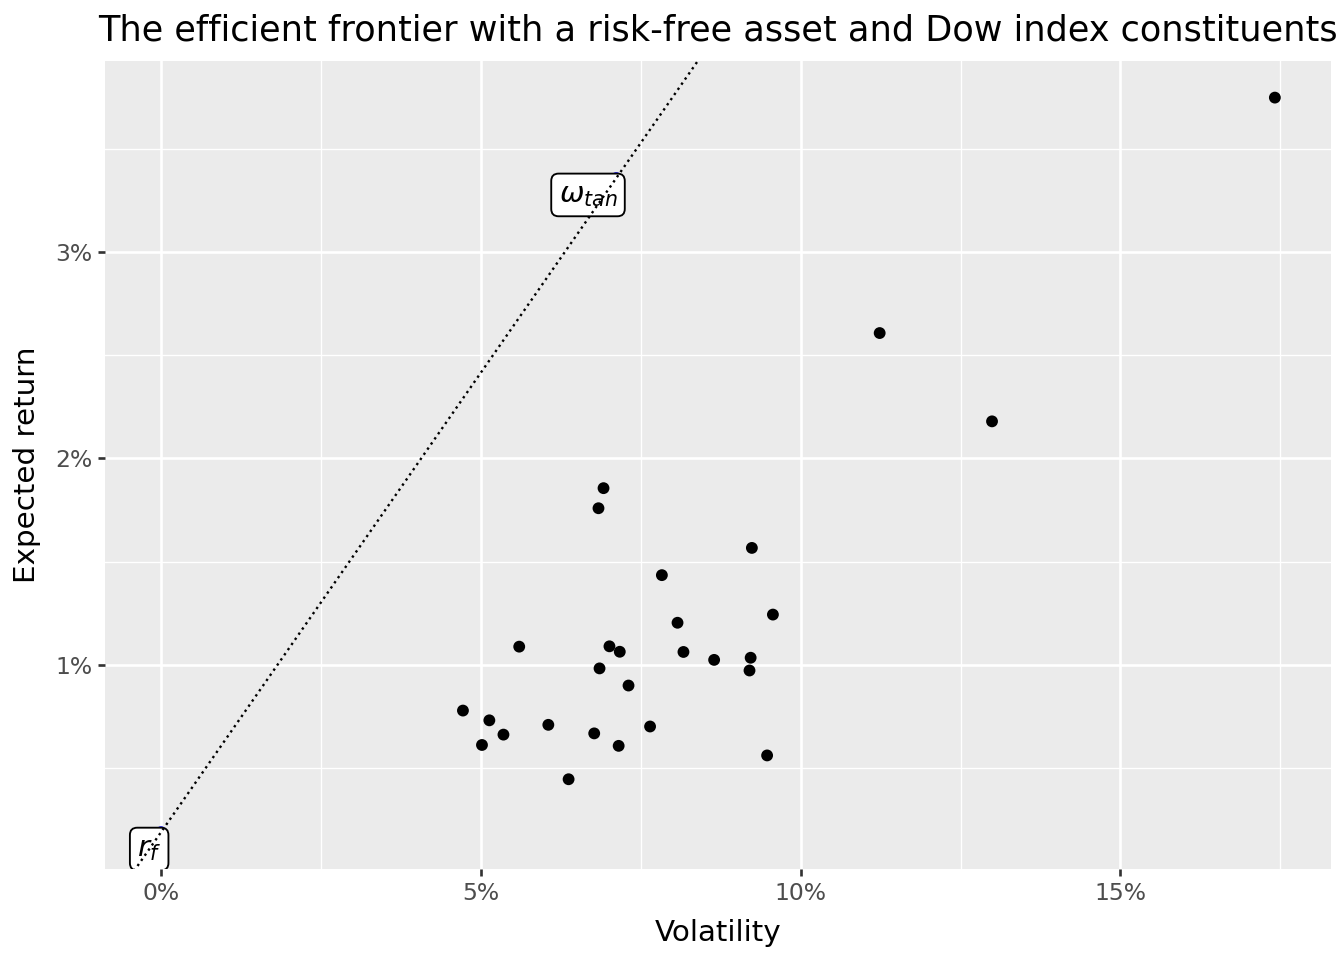

In [7]:
#| label: fig-300
#| fig-cap: Expected returns and volatilities based on monthly returns adjusted for dividend payments and stock splits.
#| fig-alt: 'Title: The efficient frontier with a risk-free asset and Dow index constituents. The figure shows a scatter plot with volatities on the horizontal axis and expected returns on the vertical axis.'
(
  ggplot(efficient_portfolios, aes(x="sigma", y="mu"))
  + geom_point(data=assets)
  + geom_point(data=efficient_portfolios, color="blue")
  + geom_label(
      aes(label="symbol"), parse=True, 
      adjust_text={"arrowprops": {"arrowstyle": "-"}}
    )
  + scale_x_continuous(labels=percent_format())
  + scale_y_continuous(labels=percent_format())
  + labs(
      x="Volatility", y="Expected return",
      title="The efficient frontier with a risk-free asset and Dow index constituents"
    )
  + geom_abline(aes(intercept=rf, slope=sharpe_ratio), linetype="dotted")
)

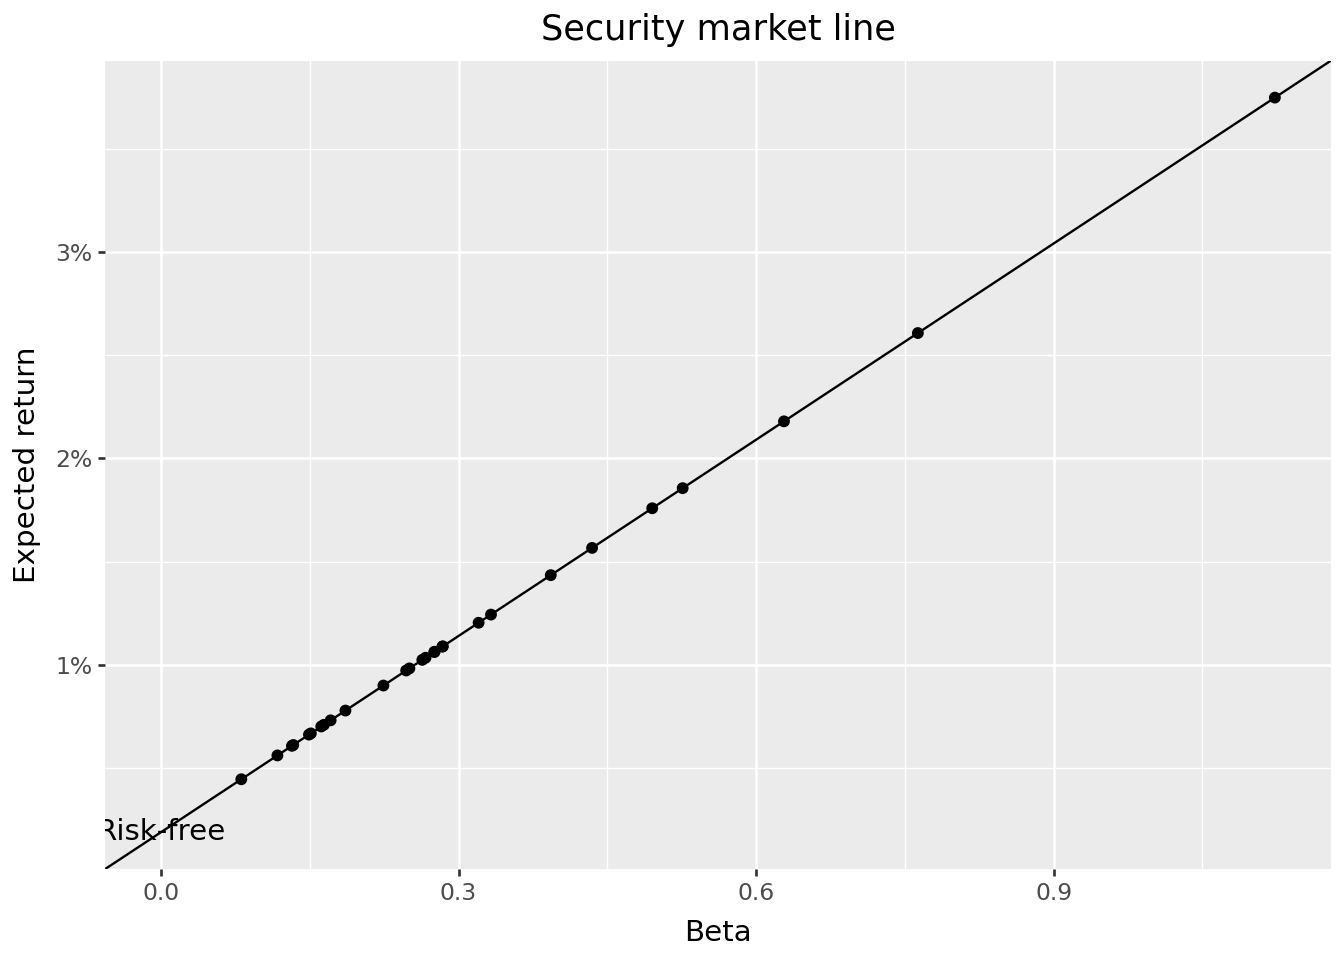

In [8]:
betas = (sigma @ w_tan) / (w_tan.T @ sigma @ w_tan)
assets["beta"] = betas.values

price_of_risk = float(w_tan.T @ mu - rf)

(
  ggplot(assets, aes(x="beta", y="mu"))
  + geom_point()
  + geom_abline(intercept=rf, slope=price_of_risk)
  + scale_y_continuous(labels=percent_format())
  + labs(
      x="Beta", y="Expected return",
      title="Security market line"
    ) 
  + annotate("text", x=0, y=rf, label="Risk-free")
)

In [9]:
# Download directly from Kenneth French's data library
url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip"
response = urllib.request.urlopen(url)
with zipfile.ZipFile(io.BytesIO(response.read())) as z:
    with z.open(z.namelist()[0]) as f:
        factors_raw = pd.read_csv(f, skiprows=3, index_col=0)

# Filter to only monthly data (index should be exactly 6 digits: YYYYMM)
factors_raw = factors_raw[factors_raw.index.astype(str).str.strip().str.match(r'^\d{6}$')]

# Convert to numeric and process
factors = (factors_raw
  .apply(pd.to_numeric, errors='coerce')
  .dropna()
  .divide(100)
  .reset_index(names="date")
  .assign(date=lambda x: pd.to_datetime(x["date"].astype(str).str.strip(), format="%Y%m"))
  .rename(str.lower, axis="columns")
  .rename(columns={"mkt-rf": "mkt_excess"})
)

In [10]:
import statsmodels.formula.api as smf

returns_excess_monthly = (returns_monthly
  .merge(factors, on="date", how="left")
  .assign(ret_excess=lambda x: x["ret"] - x["rf"])
)

def estimate_capm(data):
  model = smf.ols("ret_excess ~ mkt_excess", data=data).fit()
  result = pd.DataFrame({
    "coefficient": ["alpha", "beta"],
    "estimate": model.params.values,
    "t_statistic": model.tvalues.values
  })
  return result

capm_results = (returns_excess_monthly
  .groupby("symbol", group_keys=True)
  .apply(estimate_capm)
  .reset_index()
)

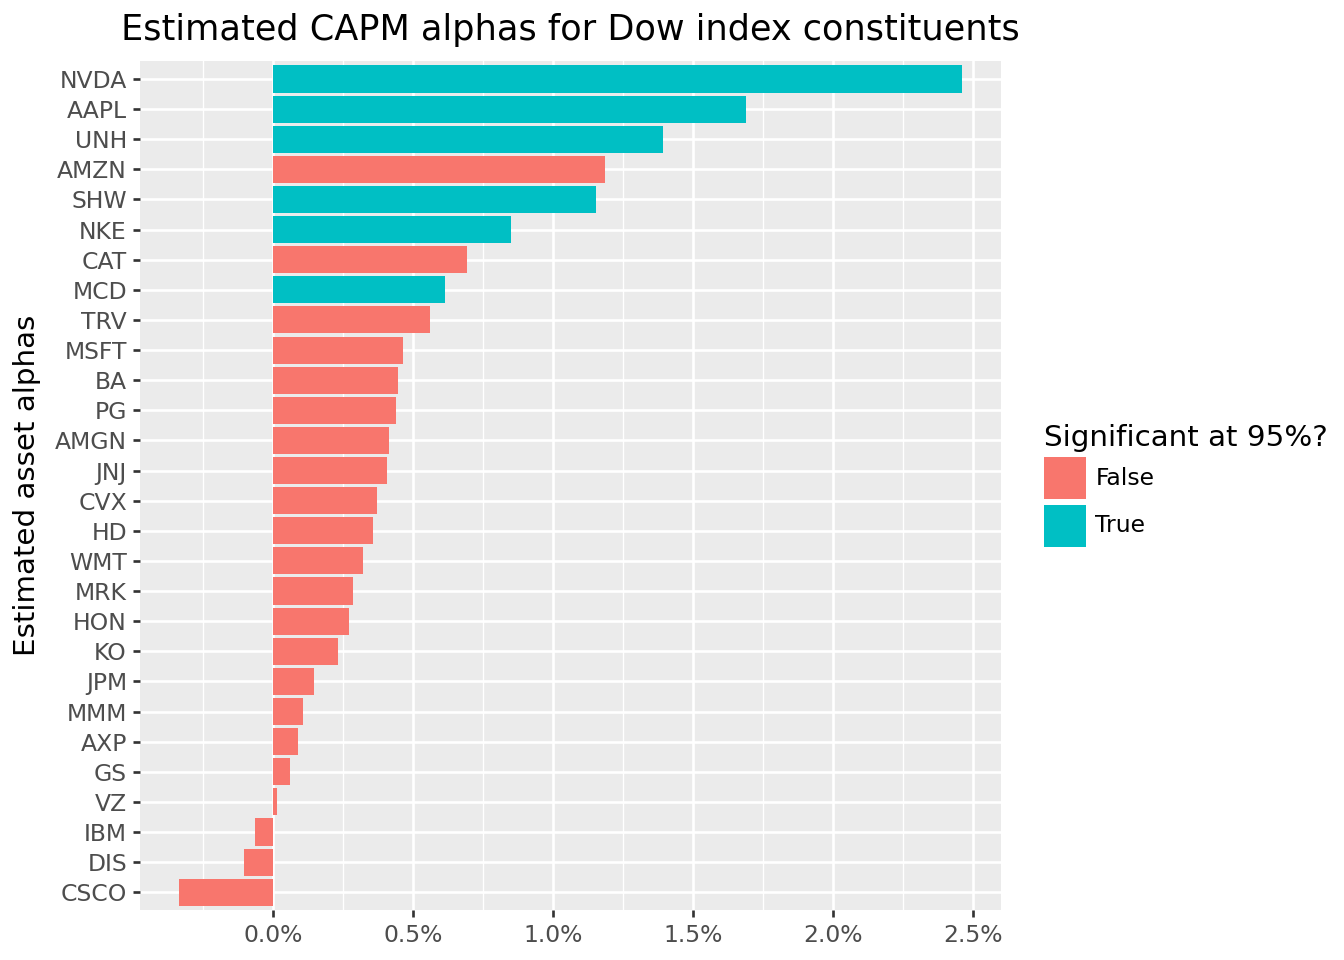

In [11]:
#| label: fig-305
#| fig-cap: Estimates are based on returns adjusted for dividend payments and stock splits and using the Fama-French market excess returns as a measure for the market.
#| fig-alt: 'Title: Estimated CAPM alphas for Dow index constituents. The figure shows a bar chart with estimated alphas and indicates whether an estimate is statistically significant at 95%. Only Nvidia exhibits a statistically significant positive alpha.'
alphas = (capm_results
  .query("coefficient=='alpha'")
  .assign(is_significant=lambda x: np.abs(x["t_statistic"]) >= 1.96)
)

alphas["symbol"] = pd.Categorical(
  alphas["symbol"],
  categories=alphas.sort_values("estimate")["symbol"],
  ordered=True
)

(
  ggplot(
    alphas,
    aes(y="estimate", x="symbol", fill="is_significant")
  )
  + geom_col()
  + scale_y_continuous(labels=percent_format())
  + coord_flip()
  + labs(
    x="Estimated asset alphas", y="", fill="Significant at 95%?",
    title="Estimated CAPM alphas for Dow index constituents"
  )
)